# Garbage Reports — EDA & Seasonality

This notebook focuses only on preparing the garbage-report time series and understanding its temporal structure.

**Main questions**
- Is there a long-term trend?
- Is there month-of-year seasonality?
- Is there day-of-week seasonality?
- Does weekly autocorrelation remain after differencing?
- Does month still matter after accounting for trend and weekday?

The forecasting/model-comparison work is kept in a separate notebook: `02_forecasting_models.ipynb`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

## 1. Configuration

In [2]:
PATH = r"data/requests.csv"

ISSUE_TYPE = "garbage"
START_YEAR = 2020
END_YEAR = 2025  # Keep only complete years for seasonality comparisons

## 2. Load and prepare the data

In [5]:
df = pd.read_csv(PATH)

df["reported"] = pd.to_datetime(df["reported"], errors="coerce")

df = (
    df.loc[
        (df["issue"] == ISSUE_TYPE)
        & (df["reported"].dt.year >= START_YEAR)
        & (df["reported"].dt.year <= END_YEAR)
    ]
    .dropna(subset=["reported"])
    .sort_values("reported")
    .copy()
)

print(f"Rows after filtering: {len(df):,}")
print(f"Date range: {df['reported'].min()} -> {df['reported'].max()}")

Rows after filtering: 46,089
Date range: 2020-01-02 07:16:29 -> 2025-12-31 15:00:22


## 3. Monthly view

Monthly aggregation is useful for examining broad trend and annual seasonality.


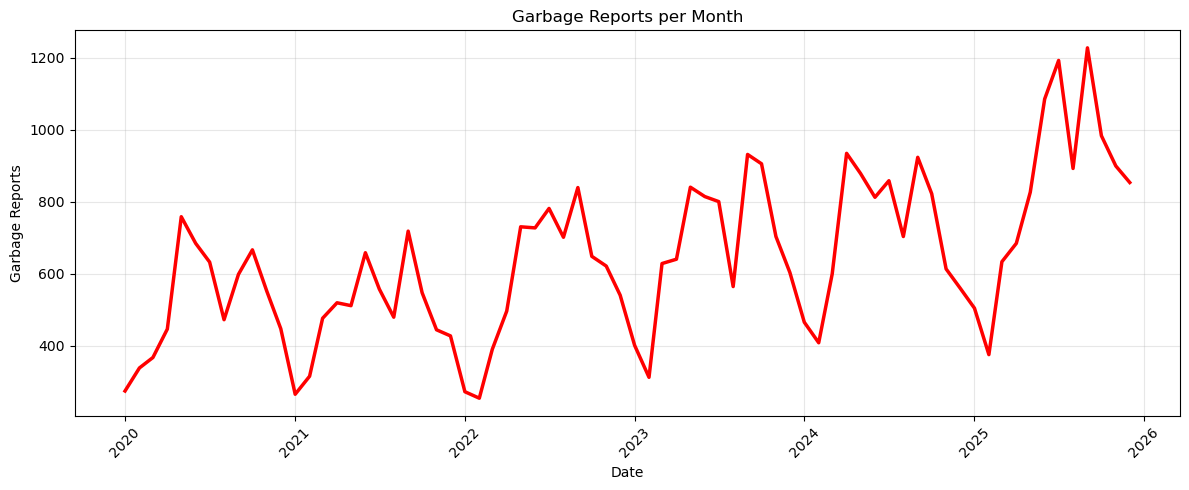

In [6]:
monthly_counts = (
    df.set_index("reported")
      .resample("MS")
      .size()
)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_counts.index,
    monthly_counts.values,
    color="red",
    linewidth=2.5
)
plt.xlabel("Date")
plt.ylabel("Garbage Reports")
plt.title("Garbage Reports per Month")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Seasonal decomposition

With monthly observations, `period=12` asks for a yearly repeating component.

This is exploratory: the decomposition extracts a 12-month pattern by construction, so it should not be treated as proof of seasonality on its own.


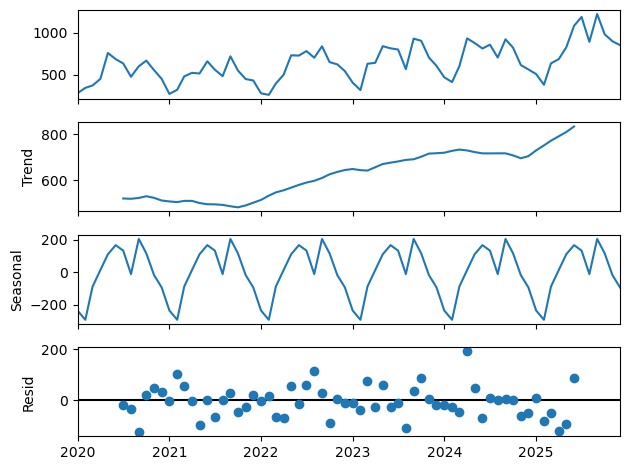

In [7]:
decomposition = seasonal_decompose(
    monthly_counts,
    model="additive",
    period=12
)

decomposition.plot()
plt.show()

### Month-of-year boxplots

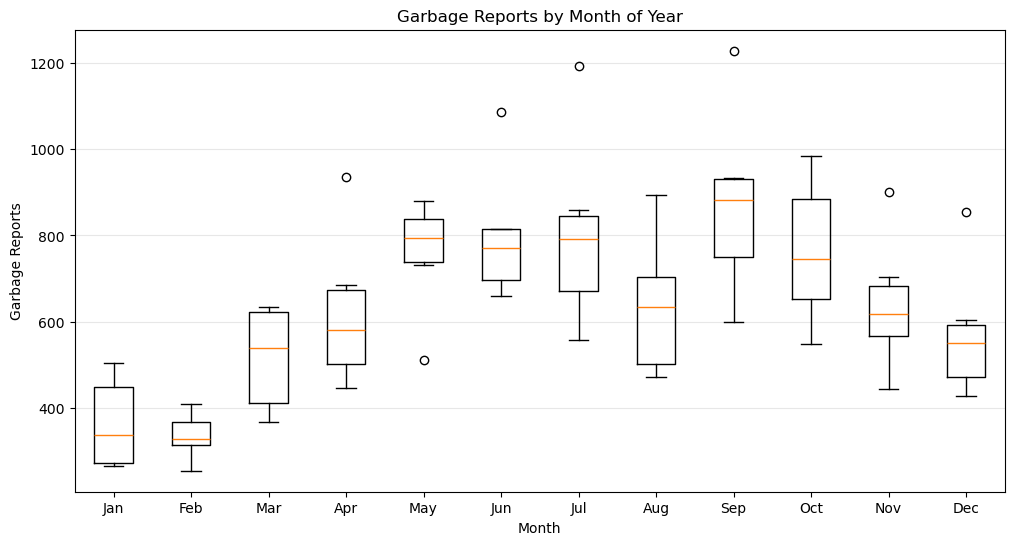

In [8]:
monthly_df = monthly_counts.reset_index(name="reports")
monthly_df["month"] = monthly_df["reported"].dt.month

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

month_data = [
    monthly_df.loc[monthly_df["month"] == month, "reports"]
    for month in range(1, 13)
]

plt.figure(figsize=(12, 6))
plt.boxplot(month_data, tick_labels=month_names)
plt.xlabel("Month")
plt.ylabel("Garbage Reports")
plt.title("Garbage Reports by Month of Year")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 4. Daily view

The raw daily series is naturally noisy. The 7-day rolling mean is added only as a visual aid; the original daily counts remain the actual observations.


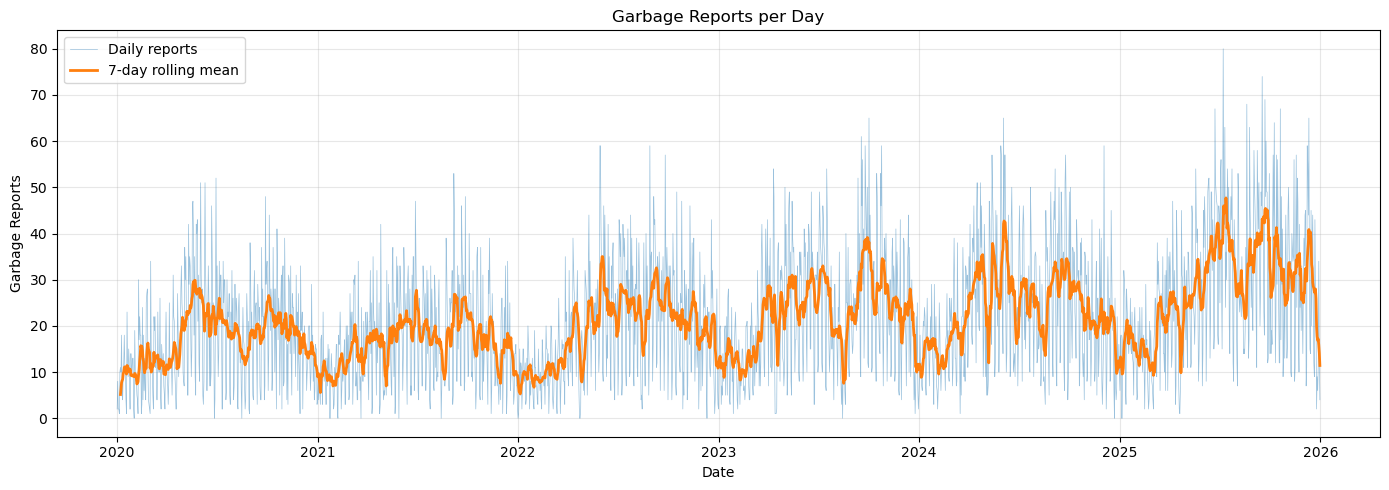

In [9]:
daily_counts = (
    df.set_index("reported")
      .resample("D")
      .size()
)

rolling_7d = daily_counts.rolling(7).mean()

plt.figure(figsize=(14, 5))
plt.plot(
    daily_counts.index,
    daily_counts.values,
    linewidth=0.5,
    alpha=0.45,
    label="Daily reports"
)
plt.plot(
    rolling_7d.index,
    rolling_7d.values,
    linewidth=2,
    label="7-day rolling mean"
)

plt.xlabel("Date")
plt.ylabel("Garbage Reports")
plt.title("Garbage Reports per Day")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Day-of-week boxplots

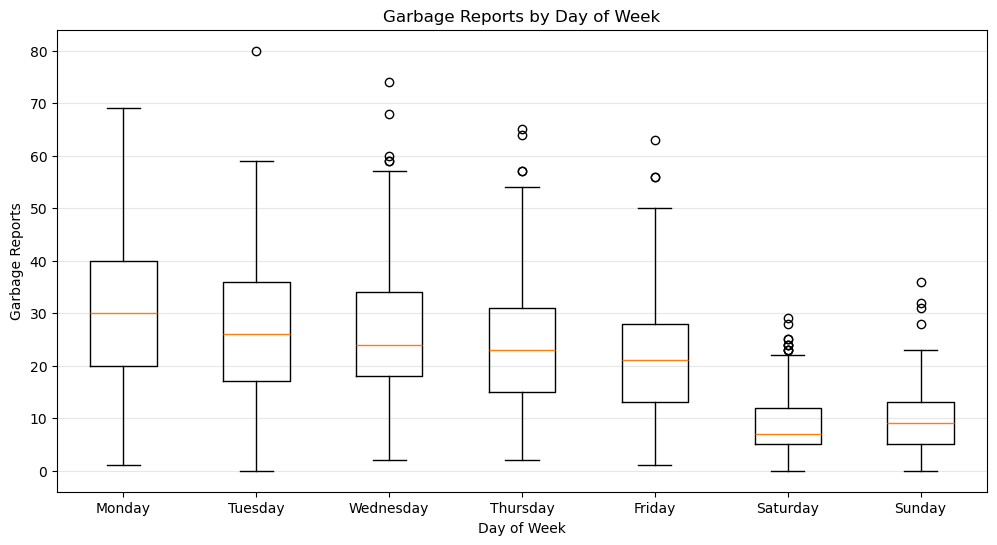

In [10]:
daily_df = daily_counts.reset_index(name="reports")

daily_df["weekday"] = daily_df["reported"].dt.day_name()
daily_df["month"] = daily_df["reported"].dt.month
daily_df["trend"] = np.arange(len(daily_df))

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_data = [
    daily_df.loc[daily_df["weekday"] == day, "reports"]
    for day in weekday_order
]

plt.figure(figsize=(12, 6))
plt.boxplot(weekday_data, tick_labels=weekday_order)
plt.xlabel("Day of Week")
plt.ylabel("Garbage Reports")
plt.title("Garbage Reports by Day of Week")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 5. Autocorrelation

For daily data, lags 7, 14, 21, ... are especially relevant because they correspond to the same weekday in previous weeks.

The second ACF uses first differences to reduce the influence of the long-term trend.


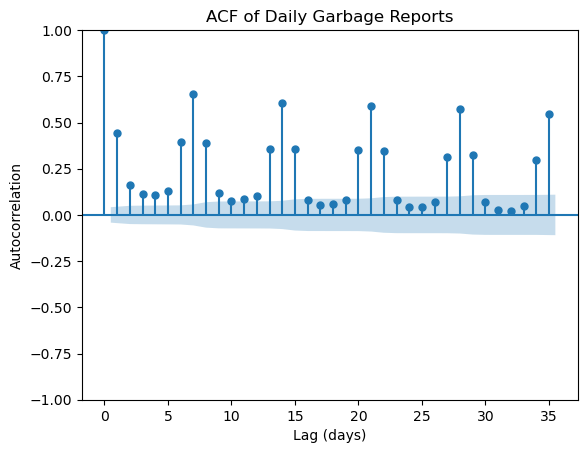

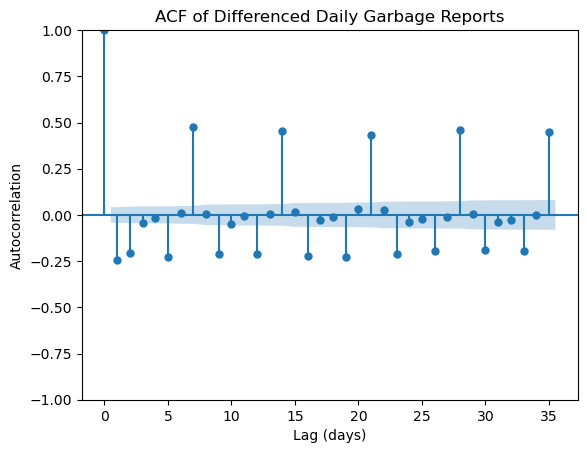

In [11]:
plot_acf(daily_counts, lags=35)
plt.xlabel("Lag (days)")
plt.ylabel("Autocorrelation")
plt.title("ACF of Daily Garbage Reports")
plt.show()

daily_diff = daily_counts.diff().dropna()

plot_acf(daily_diff, lags=35)
plt.xlabel("Lag (days)")
plt.ylabel("Autocorrelation")
plt.title("ACF of Differenced Daily Garbage Reports")
plt.show()

## 6. Does month still matter after trend + weekday?

First fit a simple exploratory regression with a linear time trend and weekday categories. Its residuals represent what remains after those effects have been accounted for.

Then inspect the residuals by month and compare two nested OLS models:
- `trend + weekday`
- `trend + weekday + month`

This is an exploratory seasonality check, not the final forecasting model.


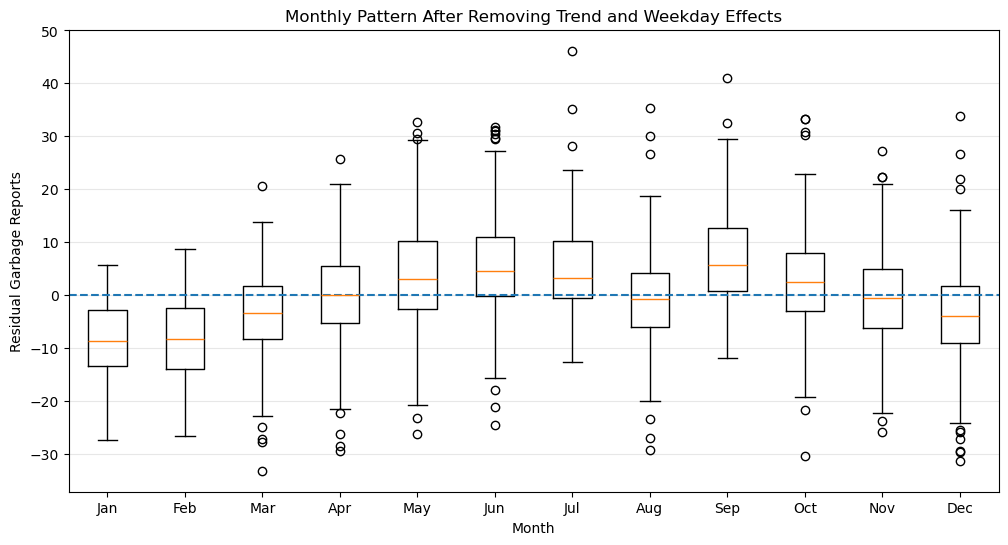

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,2183.0,227448.542711,0.0,NaN,NaN,NaN
1,2172.0,173787.334568,11.0,53661.208144,60.969054,1.641464e-118


In [12]:
trend_weekday_model = smf.ols(
    "reports ~ trend + C(weekday)",
    data=daily_df
).fit()

daily_df["residual"] = trend_weekday_model.resid

residual_month_data = [
    daily_df.loc[daily_df["month"] == month, "residual"]
    for month in range(1, 13)
]

plt.figure(figsize=(12, 6))
plt.boxplot(residual_month_data, tick_labels=month_names)
plt.axhline(0, linestyle="--")
plt.xlabel("Month")
plt.ylabel("Residual Garbage Reports")
plt.title("Monthly Pattern After Removing Trend and Weekday Effects")
plt.grid(axis="y", alpha=0.3)
plt.show()

model_without_month = smf.ols(
    "reports ~ trend + C(weekday)",
    data=daily_df
).fit()

model_with_month = smf.ols(
    "reports ~ trend + C(weekday) + C(month)",
    data=daily_df
).fit()

anova_lm(model_without_month, model_with_month)

## 7. Interpretation checklist

When reviewing the outputs, focus on:

- **Long-term trend:** monthly/daily level changes over time.
- **Weekly seasonality:** differences between weekdays and recurring ACF peaks at multiples of 7.
- **Annual seasonality:** month-to-month structure that remains after accounting for trend and weekday.
- **Caution on interpretation:** an upward trend in app reports does not necessarily imply an upward trend in actual garbage problems; increased app usage may contribute.
